<a href="https://colab.research.google.com/github/sabdaipry/fiuba-ceia-pln1/blob/main/Desafio_3_Pryszczuk_Sabrina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Desafío 3: Modelo de lenguaje con tokenización por caracteres

### 1. Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### 2. Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- `rmsprop` es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


### Importación de librerías

In [ ]:
import random
import io
import pickle
import urllib.request
import bs4 as bs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical, pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Embedding, Dropout, Input, TimeDistributed, CategoryEncoding
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [ ]:
# para poder guardar los mejores modelos después de que se entrenen
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 4. Carga de Datos (Corpus)
Utilizaremos como *dataset* el libro "La vuelta al mundo en 80 días" de Julio Verne, extraído de `textos.info.`

In [ ]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [ ]:
# Descarga del HTML
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [ ]:
# en article text se encuentra el texto de todo el libro
article_text[:2000]

" en el año 1872, la casa número 7 de saville-row, burlington gardens \n—donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a\n pesar de que parecía haber tomado el partido de no hacer nada que \npudiese llamar la atención, era uno de los miembros más notables y \nsingulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo \nse sabía que era un hombre muy galante y de los más cumplidos gentlemen \nde la alta sociedad inglesa, sucedía a uno de los más grandes oradores \nque honran a inglaterra. decíase que se daba un aire a lo byron —su cabeza, se entiende, \nporque, en cuanto a los pies, no tenía defecto alguno—, pero a un byron \nde bigote y pastillas, a un byron impasible, que hubiera vivido mil años\n sin envejecer. phileas fogg, era inglés de pura cepa; pero quizás no había nacido en\n londres. jamás se le había visto en la bolsa ni en el banco, ni en \nninguno de los despachos mercantiles de la city. ni las dársenas

### 5. Preprocesamiento y Tokenización

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [ ]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [ ]:
# El vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)
vocab_size = len(chars_vocab)

In [ ]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

In [ ]:
# Empaqueto los dos diccionarios en uno solo para mayor comodidad
diccionarios = {
    'char2idx': char2idx,
    'idx2char': idx2char
}

# Guardo el archivo .pkl en Colab
with open('diccionarios_verne.pkl', 'wb') as archivo:
    pickle.dump(diccionarios, archivo)

# Y lo copio a Drive para que no se pierda entre las desconexiones de Colab
!cp diccionarios_verne.pkl /content/drive/MyDrive/

In [ ]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

In [ ]:
tokenized_text[:1000]

[3,
 9,
 14,
 3,
 9,
 43,
 3,
 28,
 8,
 38,
 3,
 62,
 33,
 37,
 34,
 59,
 3,
 43,
 28,
 3,
 22,
 28,
 55,
 28,
 3,
 14,
 51,
 64,
 9,
 46,
 38,
 3,
 37,
 3,
 66,
 9,
 3,
 55,
 28,
 27,
 44,
 43,
 43,
 9,
 35,
 46,
 38,
 18,
 59,
 3,
 60,
 57,
 46,
 43,
 44,
 14,
 5,
 4,
 38,
 14,
 3,
 5,
 28,
 46,
 66,
 9,
 14,
 55,
 3,
 10,
 21,
 66,
 38,
 14,
 66,
 9,
 3,
 64,
 57,
 46,
 44,
 31,
 3,
 55,
 11,
 9,
 46,
 44,
 66,
 28,
 14,
 3,
 9,
 14,
 3,
 62,
 33,
 62,
 56,
 21,
 3,
 9,
 55,
 4,
 28,
 60,
 28,
 3,
 11,
 28,
 60,
 44,
 4,
 28,
 66,
 28,
 3,
 13,
 38,
 46,
 3,
 13,
 11,
 44,
 43,
 9,
 28,
 55,
 3,
 23,
 38,
 5,
 5,
 59,
 3,
 41,
 57,
 44,
 9,
 14,
 3,
 28,
 10,
 3,
 13,
 9,
 55,
 28,
 46,
 3,
 66,
 9,
 3,
 41,
 57,
 9,
 3,
 13,
 28,
 46,
 9,
 22,
 24,
 28,
 3,
 11,
 28,
 60,
 9,
 46,
 3,
 4,
 38,
 64,
 28,
 66,
 38,
 3,
 9,
 43,
 3,
 13,
 28,
 46,
 4,
 44,
 66,
 38,
 3,
 66,
 9,
 3,
 14,
 38,
 3,
 11,
 28,
 22,
 9,
 46,
 3,
 14,
 28,
 66,
 28,
 3,
 41,
 57,
 9,
 3,
 10,
 13,
 57,
 66,

### 6. Estructuración del *Dataset* (*Many-to-Many*)

Separaremos el *dataset* entre entrenamiento y validación.
Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

* **Entrada:** secuencia de tokens [$x_0, x_1, ..., x_N$]
* ***Target*:** secuencia de tokens [$x_1, x_2, ..., x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1). La ventaja es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente.

In [ ]:
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))

In [ ]:
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]

In [ ]:
# Armamos las secuencias
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]

In [ ]:
# Definimos X e y para el entrenamiento (Desfasados por 1 posición)
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

### 7. Definición de Modelos (RNN, GRU, LSTM)
El modelo consume los índices de los tokens y los transforma en vectores One-Hot Encoding (OHE). Esa transformación se logra combinando las capas `CategoryEncoding` y `TimeDistributed`.

#### a. Modelo SimpleRNN

In [ ]:
model_simple_rnn = Sequential(name="SimpleRNN_Model")

model_simple_rnn.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model_simple_rnn.add(SimpleRNN(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
model_simple_rnn.add(Dense(vocab_size, activation='softmax'))
model_simple_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model_simple_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, None, 256)      │        82,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 67)       │        17,219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,163 (391.26 KB)

 Trainable params: 100,163 (391.26 KB)

 Non-trainable params: 0 (0.00 B)

#### b. Modelo GRU

In [ ]:
model_gru = Sequential(name="GRU_Model")

model_gru.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"), input_shape=(None, 1)))
# Cambiamos SimpleRNN por GRU con 256 unidades
model_gru.add(GRU(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
model_gru.add(Dense(vocab_size, activation='softmax'))
model_gru.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
model_gru.summary()

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 256)      │       249,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 67)       │        17,219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,819 (1.02 MB)

 Trainable params: 266,819 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

#### c. Modelo LSTM

In [ ]:
model_lstm = Sequential(name="LSTM_Model")

model_lstm.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"), input_shape=(None, 1)))
# Capa LSTM con 256 unidades
model_lstm.add(LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
model_lstm.add(Dense(vocab_size, activation='softmax'))
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
model_lstm.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, None, 67)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, None, 256)      │       331,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, None, 67)       │        17,219 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,995 (1.33 MB)

 Trainable params: 348,995 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

### 8. Callback de Perplejidad
Dado que Keras no tiene una implementación nativa de la Perplejidad que evalúe secuencias completas, armamos un Callback *ad-hoc* que la calcule al final de cada epoch utilizando los datos de validación (`tokenized_sentences_val`).

In [ ]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data
      self.history_ppl = history_ppl
      # Lista para guardar la perplejidad de cada epoch

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience

      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        self.history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          # Guardamos el modelo indicando el nombre de la red
          self.model.save(f"best_model_{self.model.name}.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### 9. Entrenamiento Comparativo de Arquitecturas
Entrenaremos los tres modelos bajo las mismas condiciones. Las listas de historiales nos permitirán luego graficar y comparar cómo desciende la perplejidad en cada arquitectura.

In [ ]:
# Listas para guardar la perplejidad de cada modelo
hist_ppl_rnn = []
hist_ppl_gru = []
hist_ppl_lstm = []

In [ ]:
epochs_to_train = 30
batch_size_config = 1024

In [ ]:
print("\n" + "="*50)
print("ENTRENANDO SIMPLERNN")
print("="*50)
history_rnn = model_simple_rnn.fit(X, y, epochs=epochs_to_train, batch_size=batch_size_config,
                                   callbacks=[PplCallback(tokenized_sentences_val, history_ppl=hist_ppl_rnn)])

# Guardar modelo en Drive
!cp best_model_SimpleRNN_Model.keras /content/drive/MyDrive/


ENTRENANDO SIMPLERNN
Epoch 1/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 2.8349
 mean perplexity: 8.857367089557163 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 52s 103ms/step - loss: 2.5764
Epoch 2/30
346/348 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.3243
 mean perplexity: 7.869893849803711 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 2.2991
Epoch 3/30
346/348 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.2297
 mean perplexity: 7.090769298185552 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 2.2087
Epoch 4/30
346/348 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.1538
 mean perplexity: 6.528131759106206 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 2.1395
Epoch 5/30
346/348 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.1002
 mean perplexity: 6.180113584257019 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - loss: 2.0902
Epoch 6/30
346/348 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 2.0618
 mea

In [ ]:
print("\n" + "="*50)
print("ENTRENANDO GRU")
print("="*50)
history_gru = model_gru.fit(X, y, epochs=epochs_to_train, batch_size=batch_size_config,
                            callbacks=[PplCallback(tokenized_sentences_val, history_ppl=hist_ppl_gru)])

# Guardar modelo en Drive
!cp best_model_GRU_Model.keras /content/drive/MyDrive/


ENTRENANDO GRU
Epoch 1/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 2.9257
 mean perplexity: 9.669241290407133 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 191s 531ms/step - loss: 2.6378
Epoch 2/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 2.3468
 mean perplexity: 8.203048180202542 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 181s 520ms/step - loss: 2.3083
Epoch 3/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 2.2032
 mean perplexity: 7.34146863918014 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 180s 519ms/step - loss: 2.1752
Epoch 4/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 2.0992
 mean perplexity: 6.669587509886262 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 179s 514ms/step - loss: 2.0768
Epoch 5/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 2.0144
 mean perplexity: 6.242573281230055 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 179s 514ms/step - loss: 1.9961
Epoch 6/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 1.9

In [ ]:
print("\n" + "="*50)
print("ENTRENANDO LSTM")
print("="*50)
history_lstm = model_lstm.fit(X, y, epochs=epochs_to_train, batch_size=batch_size_config,
                              callbacks=[PplCallback(tokenized_sentences_val, history_ppl=hist_ppl_lstm)])

# Guardar modelo en Drive
!cp best_model_LSTM_Model.keras /content/drive/MyDrive/


ENTRENANDO LSTM
Epoch 1/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 3.0426
 mean perplexity: 11.720226218857741 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 182s 508ms/step - loss: 2.8264
Epoch 2/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 2.4674
 mean perplexity: 9.409717141069132 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 172s 496ms/step - loss: 2.4215
Epoch 3/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 2.3233
 mean perplexity: 8.50633892795156 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 174s 501ms/step - loss: 2.2998
Epoch 4/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 2.2389
 mean perplexity: 7.925206892986588 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 172s 494ms/step - loss: 2.2221
Epoch 5/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 2.1775
 mean perplexity: 7.54118566525164 

Saved new model!
348/348 ━━━━━━━━━━━━━━━━━━━━ 174s 500ms/step - loss: 2.1656
Epoch 6/30
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 2.

In [ ]:
# Apagar el entorno para no perder horas de GPU
from google.colab import runtime
runtime.unassign()

### 10. Comparativa de Entrenamiento (Curvas de Perplejidad)

Graficaremos el descenso de la perplejidad de las tres arquitecturas propuestas para evaluar cuál logró modelar mejor la secuencia de caracteres.

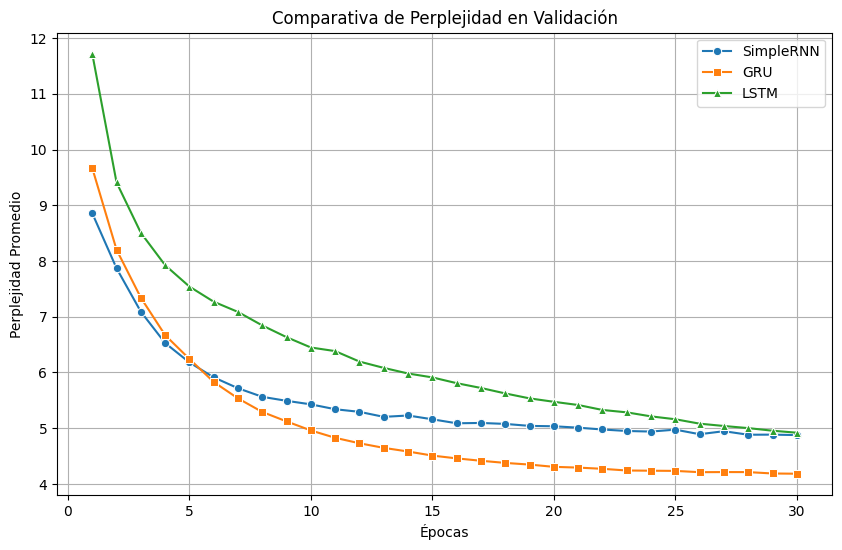

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Graficamos las 3 listas que guardamos durante el entrenamiento
sns.lineplot(x=range(1, len(hist_ppl_rnn) + 1), y=hist_ppl_rnn, label='SimpleRNN', marker='o')
sns.lineplot(x=range(1, len(hist_ppl_gru) + 1), y=hist_ppl_gru, label='GRU', marker='s')
sns.lineplot(x=range(1, len(hist_ppl_lstm) + 1), y=hist_ppl_lstm, label='LSTM', marker='^')

plt.title('Comparativa de Perplejidad en Validación')
plt.xlabel('Épocas')
plt.ylabel('Perplejidad Promedio')
plt.legend()
plt.grid(True)
plt.show()

**Comparativa de Arquitecturas y Perplejidad:**
* Al analizar las curvas de validación de 30 épocas, se observa claramente la limitación de la **SimpleRNN**, la cual tiende a estancarse rápidamente en valores de perplejidad cercanos a 5,0 debido al problema de desvanecimiento del gradiente (*vanishing gradient*) en secuencias largas.
* Por el contrario, las arquitecturas con compuertas, **GRU** y **LSTM**, demostraron una capacidad superior para capturar dependencias a largo plazo, logrando perplejidades más bajas (~4,18 para GRU y ~4,92 para LSTM en este experimento). GRU demostró ser un excelente balance entre tiempo de cómputo y rendimiento.

### 11. Funciones de Generación de Texto (Inferencia)

Cargamos las funciones provistas para codificar, decodificar y generar secuencias mediante **Greedy Search** y **Beam Search** (Determinista y Estocástico).

In [ ]:
from scipy.special import softmax

# --- Funcionalidades de encoding y decoding ---
def encode(text, max_length=max_context_size):
    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')
    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

# --- Generación Greedy Search ---
def generate_seq(model, seed_text, max_length, n_words):
    output_text = seed_text
    for _ in range(n_words):
        encoded = [char2idx[ch] for ch in output_text.lower()]
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')
        y_hat = np.argmax(model.predict(encoded, verbose=0)[0,-1,:])
        out_word = idx2char[y_hat]
        output_text += out_word
    return output_text

# --- Funciones para Beam Search ---
def select_candidates(pred, num_beams, vocab_size, history_probs, history_tokens, temp, mode):
    pred_large = []
    for idx,pp in enumerate(pred):
        pred_large.extend(np.log(pp+1E-10)+history_probs[idx])
    pred_large = np.array(pred_large)

    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams]
    elif mode == 'sto':
        idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp))
    else:
        raise ValueError(f'Wrong selection mode. {mode} was given.')

    new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T), axis=1)
    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_words, input, temp=1, mode='det'):
    encoded = encode(input)
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]
    vocab_size = y_hat.shape[0]

    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    history_probs, history_tokens = select_candidates([y_hat], num_beams, vocab_size, history_probs, history_tokens, temp, mode)

    for i in range(num_words-1):
        preds = []
        for hist in history_tokens:
            input_update = np.array([hist[i+1:]]).copy()
            y_hat = model.predict(input_update,verbose=0)[0,-1,:]
            preds.append(y_hat)

        history_probs, history_tokens = select_candidates(preds, num_beams, vocab_size, history_probs, history_tokens, temp, mode)

    return history_tokens[:,-(len(input)+num_words):]

### 12. Comparativa de Generación de Secuencias

Pondremos a prueba a los 3 modelos bajo las distintas estrategias de búsqueda. Es de esperar que LSTM y GRU generen palabras más coherentes que SimpleRNN.

In [ ]:
# 1. Cargamos desde Drive los mejores modelos que guardó nuestro Callback
best_rnn = keras.models.load_model('/content/drive/MyDrive/best_model_SimpleRNN_Model.keras')
best_gru = keras.models.load_model('/content/drive/MyDrive/best_model_GRU_Model.keras')
best_lstm = keras.models.load_model('/content/drive/MyDrive/best_model_LSTM_Model.keras')

In [ ]:
# 2. Cargamos el idioma (los diccionarios)
with open('/content/drive/MyDrive/diccionarios_verne.pkl', 'rb') as archivo:
    diccionarios_recuperados = pickle.load(archivo)

# Volvemos a crear las variables originales
char2idx = diccionarios_recuperados['char2idx']
idx2char = diccionarios_recuperados['idx2char']

In [ ]:
diccionario_modelos = {
    'SimpleRNN': best_rnn,
    'GRU': best_gru,
    'LSTM': best_lstm
}

# Texto semilla
input_text = "phileas fogg "

# Cantidad de caracteres a generar
caracteres_a_generar = 100

for nombre, modelo_eval in diccionario_modelos.items():
    print("\n" + "="*60)
    print(f"EVALUANDO MODELO: {nombre}")
    print("="*60)

    print("\n--- 1. GREEDY SEARCH ---")
    salida_greedy = generate_seq(modelo_eval, input_text, max_length=max_context_size, n_words=caracteres_a_generar)
    print(salida_greedy)

    print("\n--- 2. BEAM SEARCH DETERMINISTA ---")
    salidas_det = beam_search(modelo_eval, num_beams=5, num_words=caracteres_a_generar, input=input_text, mode='det')
    print(decode(salidas_det[0])) # Imprimimos la mejor rama

    print("\n--- 3. BEAM SEARCH ESTOCÁSTICO (Temp Baja = 0.5) ---")
    salidas_sto_baja = beam_search(modelo_eval, num_beams=5, num_words=caracteres_a_generar, input=input_text, temp=0.5, mode='sto')
    print(decode(salidas_sto_baja[0]))

    print("\n--- 4. BEAM SEARCH ESTOCÁSTICO (Temp Alta = 1.5) ---")
    salidas_sto_alta = beam_search(modelo_eval, num_beams=5, num_words=caracteres_a_generar, input=input_text, temp=1.5, mode='sto')
    print(decode(salidas_sto_alta[0]))
    print("\n")


EVALUANDO MODELO: SimpleRNN

--- 1. GREEDY SEARCH ---
phileas fogg y se había de la compañeros de la compañeros de la compañeros de la compañeros de la compañeros de l

--- 2. BEAM SEARCH DETERMINISTA ---
phileas fogg se había dispués de la compañeros de la compañeros de la compañeros de la compañeros de la compañero

--- 3. BEAM SEARCH ESTOCÁSTICO (Temp Baja = 0.5) ---
phileas fogg y su compañeros de la compañeros de los pasajeros de la manos de la compañeros de la estación de la 

--- 4. BEAM SEARCH ESTOCÁSTICO (Temp Alta = 1.5) ---
phileas fogg había que dejado a sas de la nada de la 
salida lo que la ciudad de 
salines de pasas de paso fix a 



EVALUANDO MODELO: GRU

--- 1. GREEDY SEARCH ---
phileas fogg y se había después de la mañana, y el capitán de la cabeza de la cabeza de la 
parte del "rangoon" s

--- 2. BEAM SEARCH DETERMINISTA ---
phileas fogg se había después de haber sido mister fogg, sin embargo, en cuanto a mister fogg se había después de

--- 3. BEAM SEARCH ESTOCÁST

In [ ]:
# Apagar el entorno para no perder horas de GPU
from google.colab import runtime
runtime.unassign()

### 13. Conclusiones Generales del Desafío 3

A partir del entrenamiento por 30 épocas de tres arquitecturas recurrentes (SimpleRNN, GRU y LSTM) a nivel de caracteres sobre la obra "La vuelta al mundo en 80 días", podemos extraer las siguientes conclusiones empíricas:

**1. Comparativa de Arquitecturas:**
* **SimpleRNN:** Demostró las limitaciones clásicas de las redes recurrentes simples para capturar dependencias a largo plazo. Sus textos generados, aunque forman palabras cortas en español, pierden rápidamente la coherencia sintáctica global.
* **LSTM:** Logró modelar correctamente palabras más complejas (ej. "compañía", "capitán"), pero mostró una fuerte tendencia a quedar atrapada en mínimos locales (bucles repetitivos) durante la decodificación determinista.
* **GRU:** Resultó ser la arquitectura superior en este experimento. No solo logró una mejor coherencia gramatical, sino que su memoria a largo plazo demostró ser excepcional al haber internalizado nombres propios y elementos clave de la trama presentes en el corpus original (ej. *mister fogg, francis cromarty, inglaterra, el "rangoon"*).

**2. Análisis de las Estrategias de Búsqueda y Decodificación:**
* ***Greedy Search*:** Resultó ser la estrategia más ineficiente para la generación de texto creativo. Al maximizar la probabilidad local en cada paso, los modelos LSTM y SimpleRNN entraron rápidamente en bucles infinitos (*"de la compañía de la compañía"*).
* ***Beam Search* Determinista:** Logró mitigar levemente los bucles en el modelo GRU al explorar múltiples trayectorias, generando la secuencia más coherente contextualmente (*"...después de haber sido mister fogg, sin embargo..."*).
* ***Beam Search* Estocástico (Efecto de la Temperatura):**
    * **Temperatura Baja (0.5):** Aplana moderadamente las probabilidades. Generó secuencias más seguras ortográficamente, pero con estructuras gramaticales redundantes ("conservadoras").
    * **Temperatura Alta (1.5):** Al "suavizar" drásticamente la distribución softmax, permitió a los modelos explorar ramas menos probables. Si bien esto eliminó por completo los bucles y añadió alta variabilidad, introdujo errores de ortografía e invención de términos inexistentes (ej. *diregente, miscos, salines*), demostrando la clásica compensación (*trade-off*) entre diversidad y precisión en NLP.